# Лабораторная работа №3
## Понижение размерности

**Датасет:** Breast Cancer Wisconsin (Diagnostic)

In [1]:
# Эта ячейка:
# 1) создаёт папку data, если её ещё нет;
# 2) если CSV-файл отсутствует, загружает датасет Breast Cancer Wisconsin (Diagnostic) из sklearn;
# 3) сохраняет датасет в папку проекта и показывает первые строки со всеми признаками.

from pathlib import Path
import pandas as pd
from sklearn.datasets import load_breast_cancer

# Разрешаем pandas показывать все столбцы таблицы без многоточий.
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

# Базовая папка проекта
project_root = Path("..")      # notebook лежит в папке notebooks
data_dir = project_root / "data"

# Создаём папку data, если её нет
data_dir.mkdir(parents=True, exist_ok=True)

csv_path = data_dir / "breast_cancer_wisconsin_diagnostic.csv"

# Не перезаписываем файл, если он уже есть в проекте
if not csv_path.exists():
    dataset = load_breast_cancer()
    X_df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
    y_df = pd.Series(dataset.target, name="target")
    y_label = y_df.map({0: "malignant", 1: "benign"})

    df_to_save = X_df.copy()
    df_to_save.insert(0, "diagnosis", y_label)
    df_to_save.to_csv(csv_path, index=False)
    print("CSV-файл создан на основе встроенного датасета sklearn.")
else:
    print("CSV-файл уже найден в проекте, используем его без перезаписи.")

df_preview = pd.read_csv(csv_path)

print(f"Датасет расположен: {csv_path.resolve()}")
print(f"Размер датасета: {df_preview.shape[0]} объектов, {df_preview.shape[1]} столбцов")
print("Целевая переменная: diagnosis")
print(f"Количество признаков: {df_preview.shape[1] - 1}")

df_preview.head()


CSV-файл уже найден в проекте, используем его без перезаписи.
Датасет расположен: C:\Users\bazae\Documents\IAD\data-mining-lab3\data\breast_cancer_wisconsin_diagnostic.csv
Размер датасета: 569 объектов, 31 столбцов
Целевая переменная: diagnosis
Количество признаков: 30


,diagnosis,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,malignant,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,malignant,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,malignant,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,malignant,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,malignant,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Загрузка датасета из папки проекта

In [2]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import umap.umap_ as umap

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# Скрываем техническое предупреждение UMAP, чтобы вывод оставался аккуратным.
warnings.filterwarnings(
    "ignore",
    message="n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism."
)

# Настройки отображения
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

csv_path = Path("../data/breast_cancer_wisconsin_diagnostic.csv")
df = pd.read_csv(csv_path)
print(f"Рабочий DataFrame загружен из: {csv_path.resolve()}")


Рабочий DataFrame загружен из: C:\Users\bazae\Documents\IAD\data-mining-lab3\data\breast_cancer_wisconsin_diagnostic.csv


In [3]:
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

print("Число объектов:", X.shape[0])
print("Число признаков:", X.shape[1])
print("\nРаспределение классов:")
print(y.value_counts())

Число объектов: 569
Число признаков: 30

Распределение классов:
diagnosis
benign       357
malignant    212
Name: count, dtype: int64



Датасет содержит **569 объектов** и **30 числовых признаков**.  
Целевая переменная `diagnosis` показывает тип опухоли: `malignant` или `benign`.

## Задание 1. Геометрия данных в пространстве признаков

На данном этапе необходимо:
1. определить число объектов и число признаков;
2. построить гистограммы распределения признаков;
3. построить матрицу корреляций;
4. определить наличие избыточной информации.

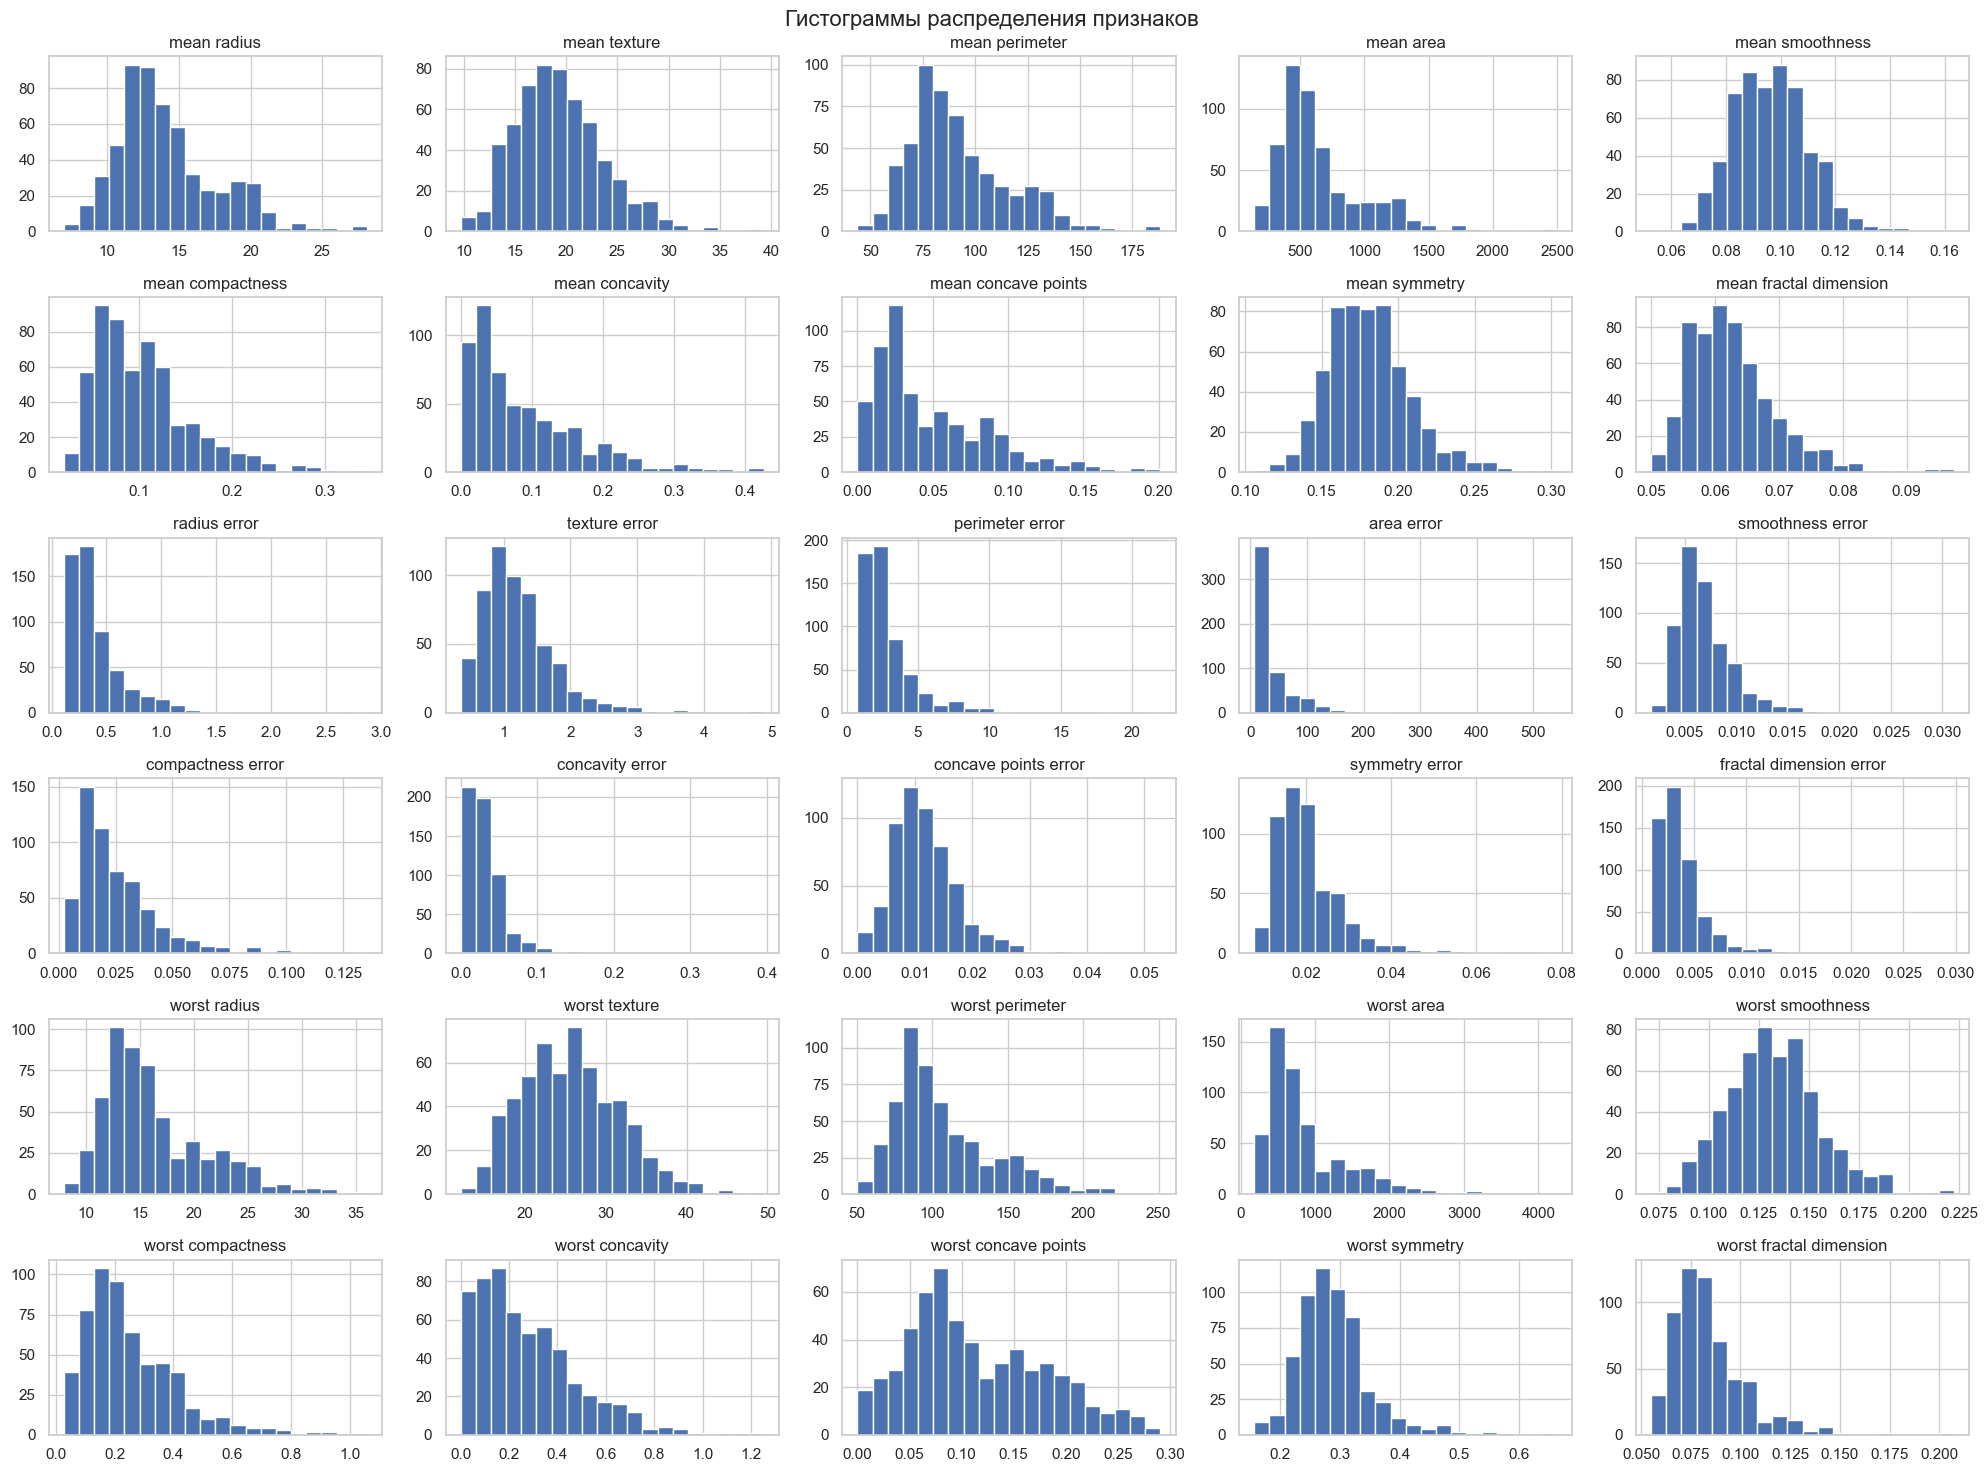

In [4]:
# Строим гистограммы распределения всех числовых признаков
# Это позволяет оценить форму распределения и возможные выбросы

X.hist(figsize=(20, 15), bins=20)
plt.suptitle("Гистограммы распределения признаков", fontsize=16)
plt.tight_layout()
plt.show()

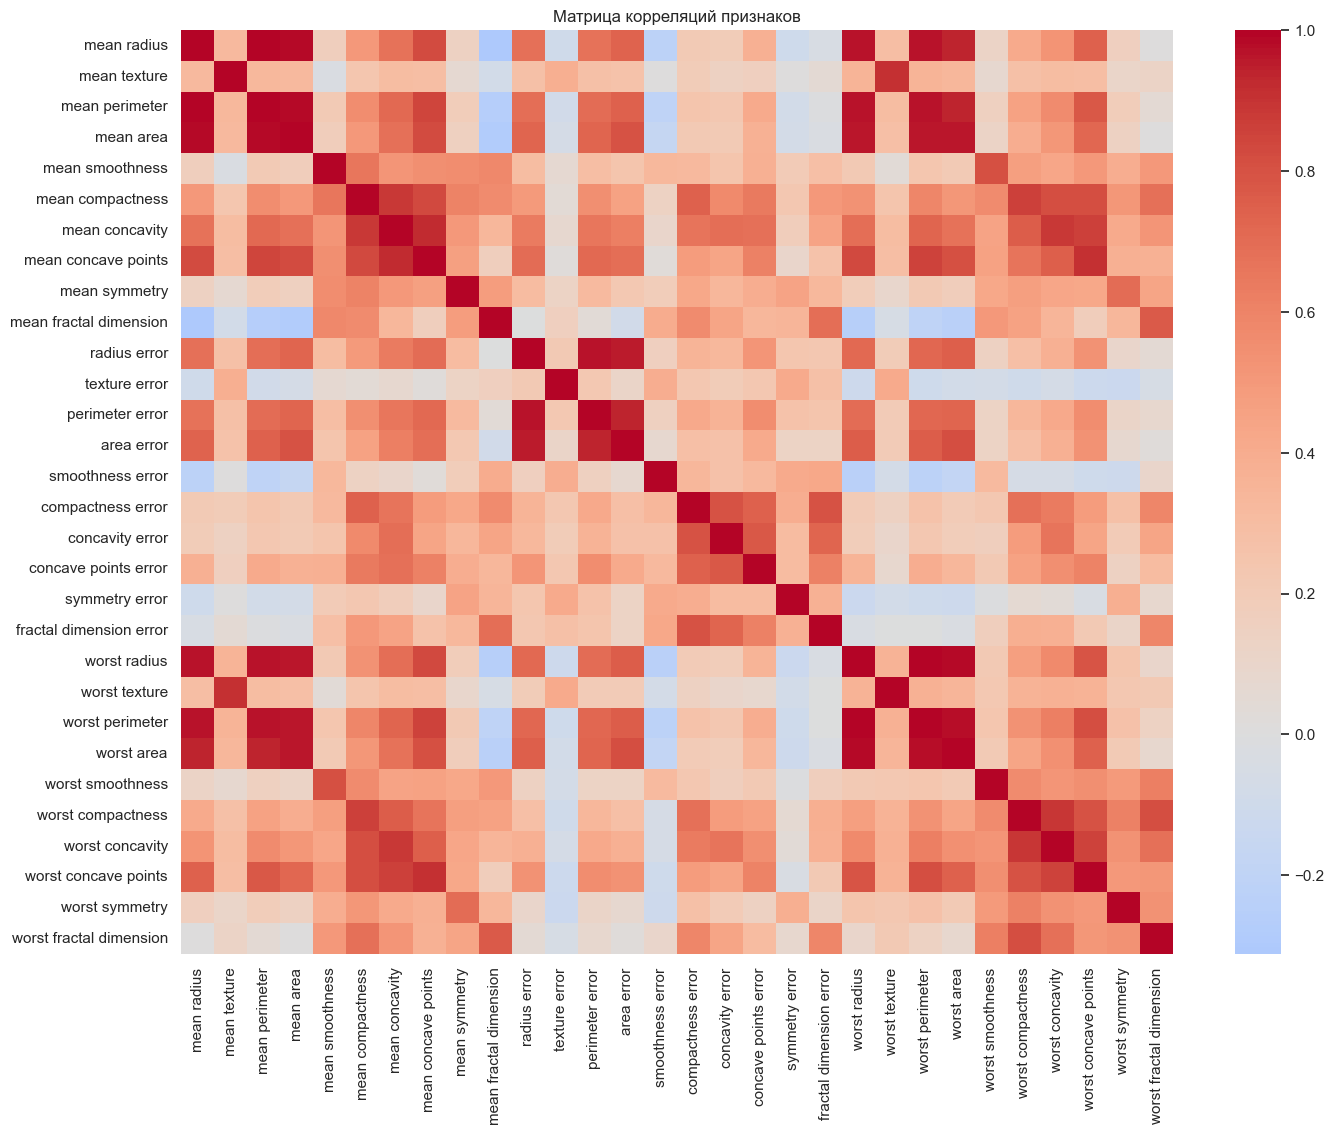

In [5]:

corr = X.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Матрица корреляций признаков")
plt.show()

In [6]:
# Ищем пары признаков с высокой корреляцией по модулю (> 0.8)

corr_abs = corr.abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

strong_corr = []
for col in upper.columns:
    for row in upper.index:
        val = upper.loc[row, col]
        if pd.notna(val) and val > 0.8:
            strong_corr.append((row, col, val))

strong_corr_df = pd.DataFrame(strong_corr, columns=["Признак 1", "Признак 2", "Корреляция"])
strong_corr_df = strong_corr_df.sort_values(by="Корреляция", ascending=False)

strong_corr_df.head(20)

,Признак 1,Признак 2,Корреляция
0,mean radius,mean perimeter,0.997855
24,worst radius,worst perimeter,0.993708
1,mean radius,mean area,0.987357
2,mean perimeter,mean area,0.986507
30,worst radius,worst area,0.984015
31,worst perimeter,worst area,0.977578
9,radius error,perimeter error,0.972794
21,mean perimeter,worst perimeter,0.970387
15,mean radius,worst radius,0.969539
16,mean perimeter,worst radius,0.969476


### Вывод по заданию 1

По матрице корреляций видно, что в датасете присутствует большое количество сильно коррелированных признаков.  
Это означает, что часть признаков содержит схожую информацию и может быть избыточной.

Следовательно, применение методов снижения размерности, таких как PCA, является оправданным.

## Задание 2. Реализация PCA с нуля

Необходимо реализовать алгоритм PCA, используя только NumPy:
1. стандартизация данных;
2. вычисление ковариационной матрицы;
3. нахождение собственных значений и собственных векторов;
4. сортировка компонент по убыванию;
5. проекция данных на первые `k` компонент.

In [7]:
# Стандартизируем данные перед применением PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
# Реализация PCA с нуля с использованием только NumPy
# 1) стандартизируем признаки;
# 2) ищем направления максимальной изменчивости данных;
# 3) проецируем объекты на новые оси.

class MyPCA:
    def __init__(self, n_components=None):
        self.n_components = n_components
        self.mean_ = None
        self.std_ = None
        self.components_ = None
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None

    def fit(self, X):
        X = np.array(X, dtype=float)

        # Сохраняем средние и стандартные отклонения,
        # чтобы потом использовать те же параметры при transform
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0)
        X_std = (X - self.mean_) / self.std_

        # Ковариационная матрица показывает,
        # как признаки изменяются совместно друг с другом
        cov_matrix = np.cov(X_std, rowvar=False)

        # Собственные векторы задают новые оси пространства,
        # а собственные значения показывают, сколько дисперсии приходится на каждую ось
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        # Сортируем компоненты по убыванию важности:
        # сначала идут направления, объясняющие максимум дисперсии
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]

        self.explained_variance_ = eigenvalues
        self.explained_variance_ratio_ = eigenvalues / np.sum(eigenvalues)

        # Оставляем либо все компоненты, либо только первые n_components
        if self.n_components is None:
            self.components_ = eigenvectors
        else:
            self.components_ = eigenvectors[:, :self.n_components]

        return self

    def transform(self, X):
        X = np.array(X, dtype=float)

        # Новые данные стандартизируем теми же параметрами,
        # что и обучающую выборку, затем проецируем на главные компоненты
        X_std = (X - self.mean_) / self.std_
        return X_std @ self.components_

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)


In [9]:
# Применяем собственную реализацию PCA и реализацию из sklearn
# Здесь нас интересует, совпадает ли общий результат уменьшения размерности

# В MyPCA стандартизация уже встроена внутрь метода fit
my_pca = MyPCA(n_components=2)
X_pca_manual = my_pca.fit_transform(X)

# В sklearn PCA подаём заранее стандартизованные данные X_scaled
sk_pca_2 = PCA(n_components=2)
X_pca_sklearn = sk_pca_2.fit_transform(X_scaled)

# Если формы совпали, значит обе реализации перевели
# 569 объектов в пространство из двух главных компонент
print("Форма результата MyPCA:", X_pca_manual.shape)
print("Форма результата sklearn PCA:", X_pca_sklearn.shape)


Форма результата MyPCA: (569, 2)
Форма результата sklearn PCA: (569, 2)


In [10]:
# Сравниваем доли объяснённой дисперсии между MyPCA и sklearn PCA
# Это уже более строгая проверка: не только размер результата, но и содержательная близость компонент

# Обучаем обе версии PCA на полном наборе компонент
my_pca_full = MyPCA()
my_pca_full.fit(X)

sk_pca_full = PCA()
sk_pca_full.fit(X_scaled)

comparison = pd.DataFrame({
    "MyPCA": my_pca_full.explained_variance_ratio_,
    "SklearnPCA": sk_pca_full.explained_variance_ratio_
})

# Смотрим максимальное расхождение между соответствующими долями дисперсии
# Если число близко к нулю, собственная реализация работает корректно
print(
    "Максимальное абсолютное различие:",
    np.max(np.abs(comparison["MyPCA"] - comparison["SklearnPCA"]))
)

# Выводим первые компоненты, потому что именно они несут основную часть информации
comparison.head(10)


Максимальное абсолютное различие: 1.6653345369377348e-16


,MyPCA,SklearnPCA
0,0.442720,0.442720
1,0.189712,0.189712
2,0.093932,0.093932
3,0.066021,0.066021
4,0.054958,0.054958
5,0.040245,0.040245
6,0.022507,0.022507
7,0.015887,0.015887
8,0.013896,0.013896
9,0.011690,0.011690


### Вывод по заданию 2

Собственная реализация PCA показывает результаты, сопоставимые с реализацией из библиотеки `sklearn`.  
Различия в знаках компонент допустимы, так как собственные векторы определяются с точностью до знака.

## Задание 2.1 Исследование объяснённой дисперсии
Построим графики доли объяснённой дисперсии и накопленной объяснённой дисперсии.

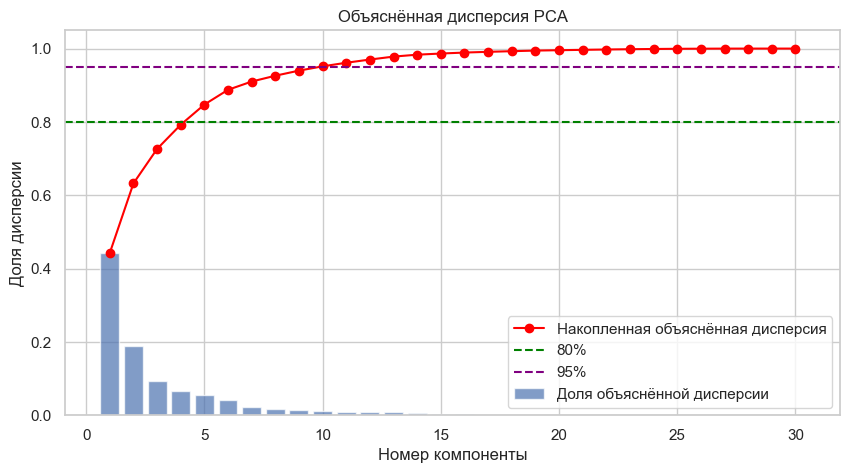

Количество компонент для 80% дисперсии: 5
Количество компонент для 95% дисперсии: 10


In [11]:
# Строим графики объяснённой дисперсии
# Они позволяют определить, сколько компонент нужно для описания 80% и 95% дисперсии

explained = sk_pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(10, 5))
plt.bar(range(1, len(explained)+1), explained, alpha=0.7, label="Доля объяснённой дисперсии")
plt.plot(range(1, len(cumulative)+1), cumulative, marker="o", color="red", label="Накопленная объяснённая дисперсия")
plt.axhline(0.80, color="green", linestyle="--", label="80%")
plt.axhline(0.95, color="purple", linestyle="--", label="95%")
plt.xlabel("Номер компоненты")
plt.ylabel("Доля дисперсии")
plt.title("Объяснённая дисперсия PCA")
plt.legend()
plt.grid(True)
plt.show()

k_80 = np.argmax(cumulative >= 0.80) + 1
k_95 = np.argmax(cumulative >= 0.95) + 1

print("Количество компонент для 80% дисперсии:", k_80)
print("Количество компонент для 95% дисперсии:", k_95)

### Вывод по исследованию объяснённой дисперсии

По графику можно определить минимальное число компонент, достаточное для сохранения основной информации:
- **80% дисперсии** объясняются первыми **5 компонентами**;
- **95% дисперсии** объясняются первыми **10 компонентами**.

Это позволяет выбрать разумную степень снижения размерности в зависимости от того, что важнее: сильнее сжать данные или точнее сохранить информацию.


## Задание 3. Интерпретация главных компонент

Рассмотрим первые три главные компоненты и определим признаки с наибольшим вкладом.

In [12]:
# Вычисляем первые три главные компоненты и смотрим коэффициенты признаков в них.
# Выводим полную таблицу коэффициентов для всех 30 признаков.

pca3 = PCA(n_components=3)
pca3.fit(X_scaled)

loadings = pd.DataFrame(
    pca3.components_.T,
    columns=["PC1", "PC2", "PC3"],
    index=X.columns
)

loadings.round(4)


,PC1,PC2,PC3
mean radius,0.2189,-0.2339,-0.0085
mean texture,0.1037,-0.0597,0.0645
mean perimeter,0.2275,-0.2152,-0.0093
mean area,0.2210,-0.2311,0.0287
mean smoothness,0.1426,0.1861,-0.1043
mean compactness,0.2393,0.1519,-0.0741
mean concavity,0.2584,0.0602,0.0027
mean concave points,0.2609,-0.0348,-0.0256
mean symmetry,0.1382,0.1903,-0.0402
mean fractal dimension,0.0644,0.3666,-0.0226


In [ ]:
# Для каждой из первых трёх компонент выводим признаки с наибольшими по модулю коэффициентами
# Показываем результат отдельными таблицами, чтобы вывод не обрезался

from IPython.display import display

for pc in ["PC1", "PC2", "PC3"]:
    print(f"Топ-10 признаков для {pc}:")

    top_features = (
        loadings[pc]
        .sort_values(key=np.abs, ascending=False)
        .head(10)
        .rename("Коэффициент")
        .to_frame()
        .reset_index()
        .rename(columns={"index": "Признак"})
        .round(4)
    )

    display(top_features)


Топ-10 признаков для PC1:


,Признак,Коэффициент
0,mean concave points,0.2609
1,mean concavity,0.2584
2,worst concave points,0.2509
3,mean compactness,0.2393
4,worst perimeter,0.2366
5,worst concavity,0.2288
6,worst radius,0.2280
7,mean perimeter,0.2275
8,worst area,0.2249
9,mean area,0.2210


Топ-10 признаков для PC2:


,Признак,Коэффициент
0,mean fractal dimension,0.3666
1,fractal dimension error,0.2801
2,worst fractal dimension,0.2753
3,mean radius,-0.2339
4,compactness error,0.2327
5,mean area,-0.2311
6,worst radius,-0.2199
7,worst area,-0.2194
8,mean perimeter,-0.2152
9,smoothness error,0.2044


Топ-10 признаков для PC3:


,Признак,Коэффициент
0,texture error,0.3746
1,smoothness error,0.3088
2,symmetry error,0.2886
3,worst symmetry,-0.2713
4,radius error,0.2685
5,perimeter error,0.2666
6,worst smoothness,-0.2598
7,worst compactness,-0.2361
8,worst fractal dimension,-0.2328
9,concave points error,0.2247


### Вывод по заданию 3

На первую главную компоненту сильнее всего влияют признаки, связанные с размером опухоли и выраженностью её границ: `mean concave points`, `mean concavity`, `mean compactness`, `mean perimeter`, `mean area`, а также соответствующие `worst`-признаки.

Поэтому первую компоненту можно интерпретировать как линейную комбинацию исходных признаков, отражающую общий масштаб и степень выраженности опухолевых изменений.

Признаки с малыми по модулю коэффициентами почти не влияют на первые компоненты, значит их вклад в основную структуру данных невелик.


## Задание 4. Визуализация данных

Сравним визуализацию по двум исходным признакам и по двум главным компонентам.

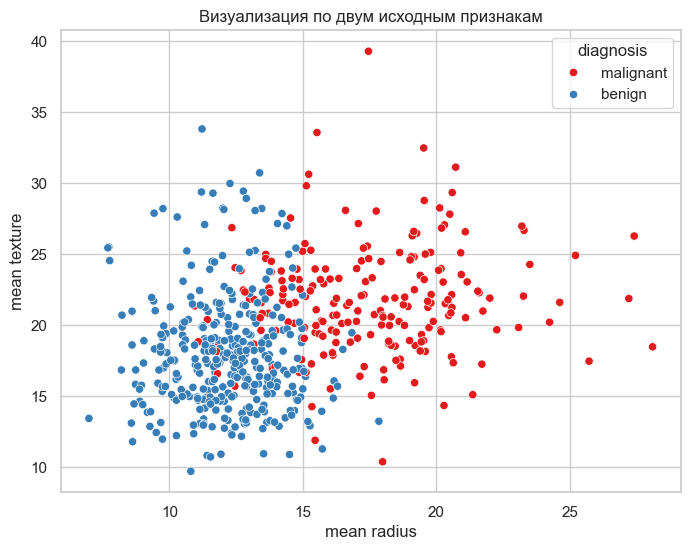

In [ ]:
# Строим диаграмму рассеяния по двум исходным признакам
# Для сравнения используем признаки mean radius и mean texture

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X["mean radius"],
    y=X["mean texture"],
    hue=y,
    palette="Set1"
)
plt.title("Визуализация по двум исходным признакам")
plt.xlabel("mean radius")
plt.ylabel("mean texture")
plt.show()


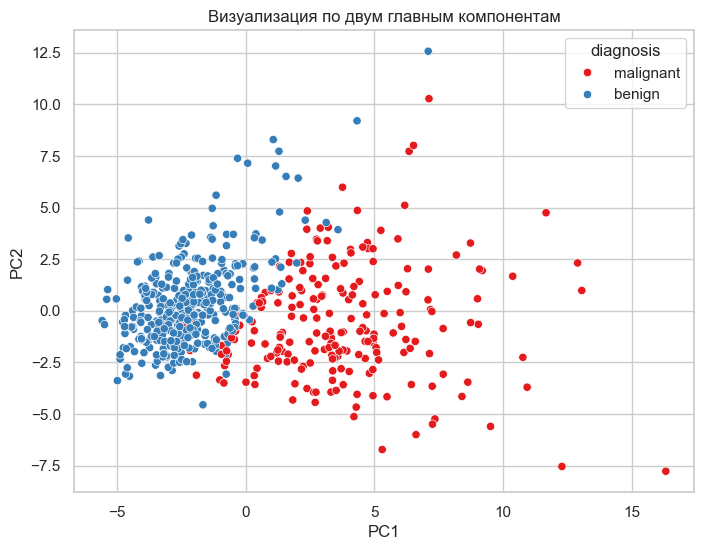

In [ ]:
# Строим визуализацию объектов в пространстве первых двух главных компонент

pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca2[:, 0],
    y=X_pca2[:, 1],
    hue=y,
    palette="Set1"
)
plt.title("Визуализация по двум главным компонентам")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

### Вывод по заданию 4

После применения PCA структура данных стала заметнее.  
Это связано с тем, что главные компоненты концентрируют основную дисперсию данных и уменьшают влияние избыточных признаков.

Поэтому в пространстве главных компонент группы объектов могут разделяться лучше, чем в пространстве исходных признаков.

## Задание 5. Нелинейные методы снижения размерности

Применим методы:
- t-SNE
- UMAP

и исследуем влияние параметров на структуру двумерной проекции.

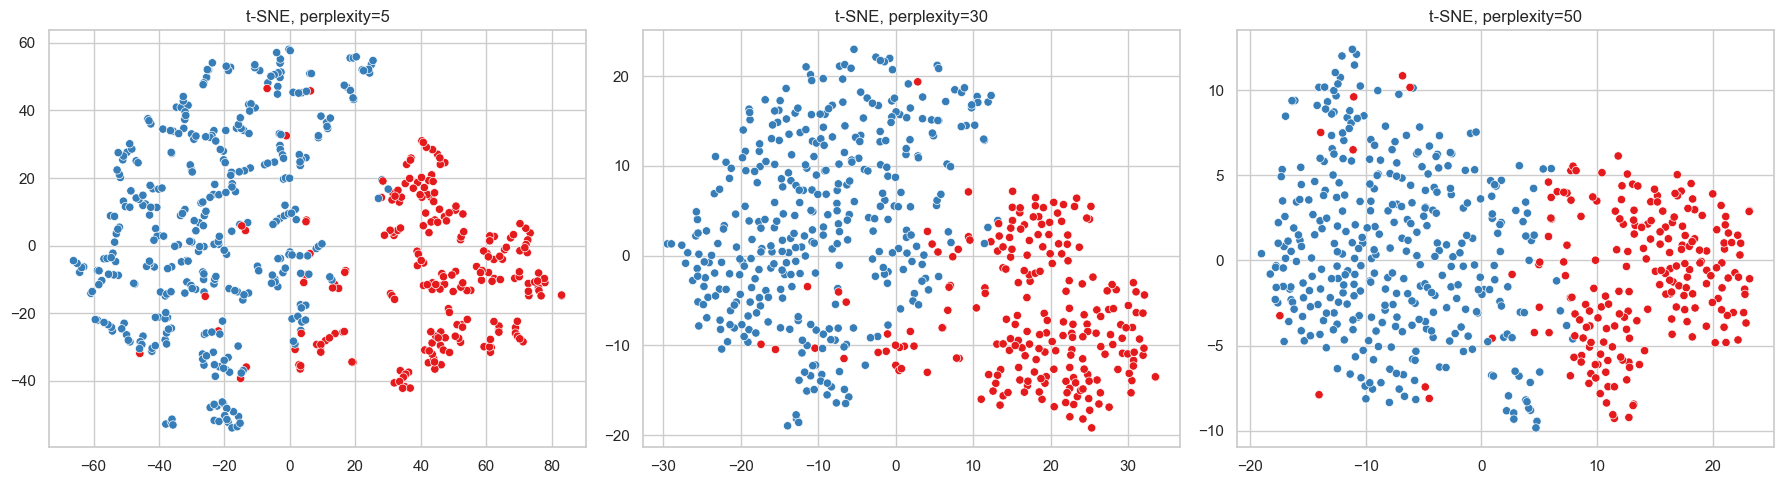

In [16]:
# Строим несколько визуализаций t-SNE с разными значениями perplexity.

perplexities = [5, 30, 50]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, perp in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)

    sns.scatterplot(
        x=X_tsne[:, 0],
        y=X_tsne[:, 1],
        hue=y,
        palette="Set1",
        ax=axes[i],
        legend=False
    )
    axes[i].set_title(f"t-SNE, perplexity={perp}")

plt.tight_layout()
plt.show()

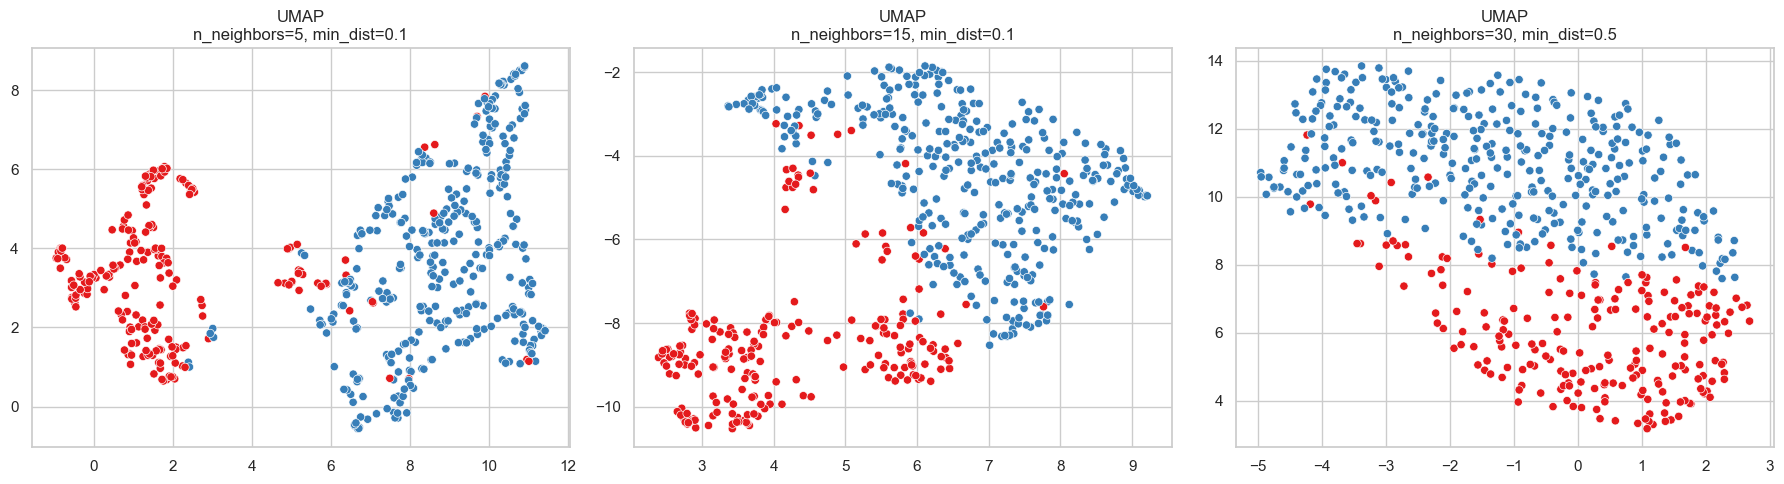

In [17]:
# Строим несколько визуализаций UMAP с разными параметрами n_neighbors и min_dist.

params = [
    (5, 0.1),
    (15, 0.1),
    (30, 0.5)
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (n_neighbors, min_dist) in enumerate(params):
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        random_state=42
    )
    X_umap = reducer.fit_transform(X_scaled)

    sns.scatterplot(
        x=X_umap[:, 0],
        y=X_umap[:, 1],
        hue=y,
        palette="Set1",
        ax=axes[i],
        legend=False
    )
    axes[i].set_title(f"UMAP\nn_neighbors={n_neighbors}, min_dist={min_dist}")

plt.tight_layout()
plt.show()

### Вывод по заданию 5

В t-SNE при малом `perplexity` сильнее проявляется локальная структура, а при больших значениях карта становится более сглаженной.
В UMAP параметры `n_neighbors` и `min_dist` заметно влияют на компактность групп и на то, насколько хорошо сохраняется общая форма данных.

Для этого датасета наиболее интерпретируемой оказалась визуализация UMAP: классы разделяются достаточно чётко, а расположение групп выглядит более устойчивым.
Результаты разных методов отличаются, потому что они по-разному сохраняют расстояния, соседства и глобальную геометрию при переходе в двумерное пространство.


## Задание 6. Исследование степени сжатия данных

Оценим, как уменьшение числа компонент влияет на точность восстановления исходных данных.

In [18]:
# Для разных значений числа компонент:
# 1) уменьшаем размерность;
# 2) восстанавливаем данные обратным преобразованием;
# 3) считаем MSE между исходными и восстановленными данными.

ks = [2, 5, 10, 15]
results = []

for k in ks:
    pca = PCA(n_components=k)
    X_reduced = pca.fit_transform(X_scaled)
    X_reconstructed = pca.inverse_transform(X_reduced)

    mse = mean_squared_error(X_scaled, X_reconstructed)
    results.append((k, mse))

results_df = pd.DataFrame(results, columns=["Число компонент", "Ошибка восстановления"])
results_df

,Число компонент,Ошибка восстановления
0,2,0.367568
1,5,0.152657
2,10,0.048431
3,15,0.013512


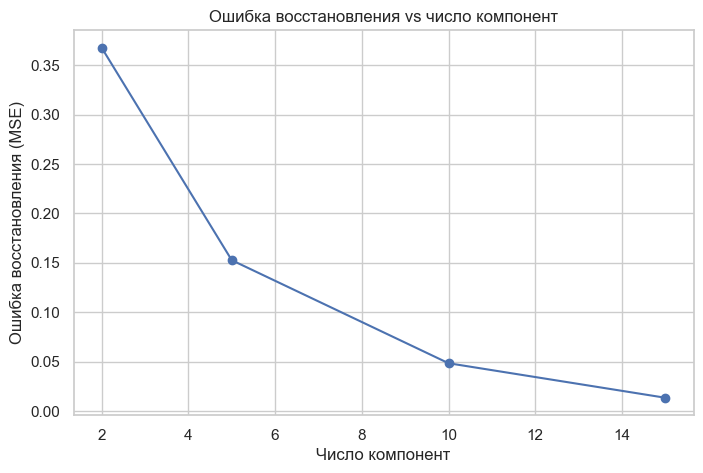

In [19]:
# Строим график зависимости ошибки восстановления от числа компонент.

plt.figure(figsize=(8, 5))
plt.plot(results_df["Число компонент"], results_df["Ошибка восстановления"], marker="o")
plt.xlabel("Число компонент")
plt.ylabel("Ошибка восстановления (MSE)")
plt.title("Ошибка восстановления vs число компонент")
plt.grid(True)
plt.show()

### Вывод по заданию 6

При малом числе компонент ошибка восстановления велика, потому что значительная часть дисперсии отбрасывается.
С увеличением числа компонент ошибка уменьшается, так как сохраняется больше информации об исходных данных.

Если использовать все компоненты, данные можно восстановить практически полностью с точностью до численных ошибок.
Это напрямую связано с объяснённой дисперсией PCA: чем она выше, тем меньше ошибка реконструкции.

Для этого датасета разумным компромиссом можно считать диапазон **5-10 компонент**: размерность уже заметно снижена, а ошибка восстановления существенно уменьшается.


## Задание 7. Итоговый анализ

1. Снижение размерности помогает убрать избыточность признаков, упростить визуализацию и сделать структуру данных более понятной.
2. Уменьшение размерности полезно не всегда: при слишком сильном сжатии можно потерять важную информацию.
3. Линейные методы работают хуже нелинейных, если структура данных не описывается линейными комбинациями исходных признаков.
4. PCA хорошо интерпретируется и позволяет анализировать долю сохранённой информации, но учитывает только линейные зависимости. t-SNE хорошо показывает локальные группы, а UMAP часто лучше сохраняет общую структуру и даёт удобную визуализацию, однако оба метода чувствительны к параметрам.

В этой работе PCA оказался особенно полезен для анализа дисперсии и интерпретации признаков, а t-SNE и UMAP — для наглядной двумерной визуализации объектов.
